In [1]:
import numpy as np

filename = "noisy_16.txt"

x = []
y = []

with open(filename, "r") as file:
    for line in file:
        values = line.strip().split()

        if len(values) == 2:
            x.append(float(values[0]))
            y.append(float(values[1]))

print("Number of samples:", len(x))
print("First 5 x values:", x[:5])
print("First 5 y values:", y[:5])

Number of samples: 10000
First 5 x values: [-100.0, -99.97999799979998, -99.95999599959995, -99.93999399939995, -99.91999199919992]
First 5 y values: [-47.71166839575894, -43.879063686327285, -38.618688850789034, -49.53784635644776, -59.965372407708756]


In [2]:
# Here we Shuffle the data using NumPy
import random

data = list(zip(x, y))

random.seed(42) # Keeps the randomness constant every time you run it
random.shuffle(data)

x = np.array([row[0] for row in data])
y = np.array([row[1] for row in data])

print("First 5 shuffled samples:")
for i in range(5):
    print(x[i], y[i])


First 5 shuffled samples:
-24.572457245724564 -30.914341760480163
33.45334533453345 -55.86602717121794
45.23452345234523 -68.13658492983173
-84.7984798479848 -44.19278927534317
-24.41244124412441 -44.68722040244906


In [3]:
# Splitting of datasets into train, test and validation

# Test : 20%
# Train : 60%
# Validation : 20%

n = len(x)

train_end = int(0.60 * n)
test_end = int(0.80 * n)

x_train = x[:train_end]
y_train = y[:train_end]

x_test = x[train_end:test_end]
y_test = y[train_end:test_end]

x_val = x[test_end:]
y_val = y[test_end:]

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))
print("Validation samples:", len(x_val))


Training samples: 6000
Test samples: 2000
Validation samples: 2000


In [4]:
# Scaling of dataset
x_train_scaled = np.asarray(x_train) / 100.0
x_test_scaled = np.asarray(x_test) / 100.0
x_val_scaled = np.asarray(x_val) / 100.0

print("Original x:", x_train[:5])
print("Scaled x:", x_train_scaled[:5])


Original x: [-24.57245725  33.45334533  45.23452345 -84.79847985 -24.41244124]
Scaled x: [-0.24572457  0.33453345  0.45234523 -0.8479848  -0.24412441]


In [5]:
def create_polynomial_matrix(x, degree):
    x = np.asarray(x)
    return np.column_stack([x ** power for power in range(degree + 1)])


In [6]:
# NumPy handles matrix transpose using .T
# Example: A.T


In [7]:
# NumPy handles matrix multiplication using @
# Example: A @ B


In [8]:
# NumPy provides matrix inversion through np.linalg.inv().
# For regression below, np.linalg.solve() is preferred for numerical stability.


In [9]:
# Implementation of Polynomial Regression using NumPy
# β = (XᵀX)⁻¹Xᵀy

def polynomial_regression(x, y, degree):

    # Create polynomial feature matrix
    X = create_polynomial_matrix(x, degree)
    y = np.asarray(y).reshape(-1, 1)

    # XᵀX
    XTX = X.T @ X

    # Xᵀy
    XTY = X.T @ y

    # β = (XᵀX)⁻¹Xᵀy
    # np.linalg.solve avoids explicitly computing the inverse.
    beta = np.linalg.solve(XTX, XTY)

    return beta.flatten()


In [10]:
# Prediction using NumPy matrix multiplication
def predict(x, coefficients):
    X = create_polynomial_matrix(x, len(coefficients) - 1)
    return X @ np.asarray(coefficients)


In [11]:
# Mean Squared Error using NumPy
def mean_squared_error(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean((y_true - y_pred) ** 2)


In [12]:
#Test different polynomial degrees
degrees = range(1, 20)

results = []

for degree in degrees:

    coefficients = polynomial_regression(
        x_train_scaled,
        y_train,
        degree
    )

    train_predictions = predict(
        x_train_scaled,
        coefficients
    )

    test_predictions = predict(
        x_test_scaled,
        coefficients
    )

    train_mse = mean_squared_error(
        y_train,
        train_predictions
    )

    test_mse = mean_squared_error(
        y_test,
        test_predictions
    )

    results.append((degree, train_mse, test_mse))

    print(
        "Degree:", degree,
        "| Train MSE:", train_mse,
        "| Test MSE:", test_mse
    )

Degree: 1 | Train MSE: 1602.5663468252328 | Test MSE: 1558.2572852770152
Degree: 2 | Train MSE: 1602.55918283079 | Test MSE: 1558.324357090812
Degree: 3 | Train MSE: 1389.7931452331134 | Test MSE: 1367.5774803372583
Degree: 4 | Train MSE: 1389.4385948314316 | Test MSE: 1366.2786356566744
Degree: 5 | Train MSE: 1308.9402866361477 | Test MSE: 1304.1032844838373
Degree: 6 | Train MSE: 907.3815801516574 | Test MSE: 911.9496007945183
Degree: 7 | Train MSE: 785.038541694629 | Test MSE: 792.4779587859205
Degree: 8 | Train MSE: 319.0862662563545 | Test MSE: 321.1125782030431
Degree: 9 | Train MSE: 319.08489775949835 | Test MSE: 321.0876340894646
Degree: 10 | Train MSE: 319.0839612769549 | Test MSE: 321.1057499136476
Degree: 11 | Train MSE: 319.0167435140113 | Test MSE: 321.01900454411634
Degree: 12 | Train MSE: 318.93663595458133 | Test MSE: 321.4497425488372
Degree: 13 | Train MSE: 318.6210129340141 | Test MSE: 321.88177970303957
Degree: 14 | Train MSE: 318.603829362111 | Test MSE: 321.903117

In [13]:
# Select the best degree
best_degree = results[0][0]
best_test_mse = results[0][2]

for degree, train_mse, test_mse in results:

    if test_mse < best_test_mse:

        best_degree = degree
        best_test_mse = test_mse

print("Best polynomial degree:", best_degree)
print("Best test MSE:", best_test_mse)

Best polynomial degree: 11
Best test MSE: 321.01900454411634


In [14]:
# Final validation evaluation
best_coefficients = polynomial_regression(
    x_train_scaled,
    y_train,
    best_degree
)

validation_predictions = predict(
    x_val_scaled,
    best_coefficients
)

validation_mse = mean_squared_error(
    y_val,
    validation_predictions
)

print("Selected degree:", best_degree)
print("Validation MSE:", validation_mse)

Selected degree: 11
Validation MSE: 316.5776021650906


In [15]:
#--------------------------ADDITIONAL EXPERIMENTS OF POLYNOMIAL REGRESSION ASSIGNMENT-----------------------------#

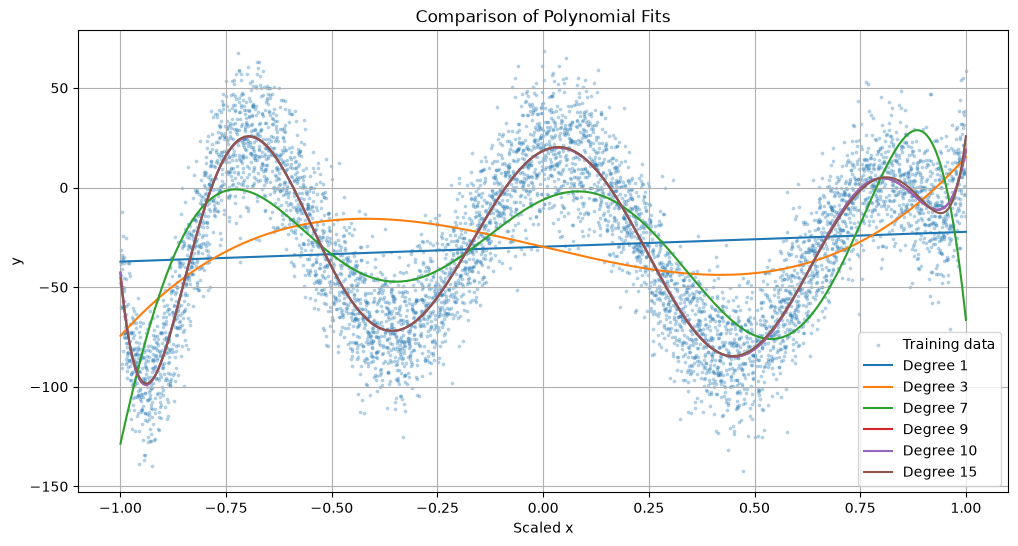

In [ ]:
# EXPERIMENT - 1
# Visual comparison of polynomial fits

import matplotlib.pyplot as plt

# Degrees we want to compare
plot_degrees = [1, 3, 7, 9, 11, 13, 15]

# Sort training data for a smooth curve
sorted_data = sorted(zip(x_train_scaled, y_train))

plot_x = [item[0] for item in sorted_data]
plot_y = [item[1] for item in sorted_data]

plt.figure(figsize=(12, 6))

# Plot noisy training data
plt.scatter(
    plot_x,
    plot_y,
    s=3,
    alpha=0.25,
    label="Training data"
)

# Generate smooth x values
curve_x = []

for i in range(-200, 201):
    curve_x.append(i / 200.0)

# Plot each polynomial
for degree in plot_degrees:

    coefficients = polynomial_regression(
        x_train_scaled,
        y_train,
        degree
    )

    curve_y = predict(
        curve_x,
        coefficients
    )

    plt.plot(
        curve_x,
        curve_y,
        label=f"Degree {degree}"
    )

plt.xlabel("Scaled x")
plt.ylabel("y")
plt.title("Comparison of Polynomial Fits")
plt.legend()
plt.grid(True)

plt.show()

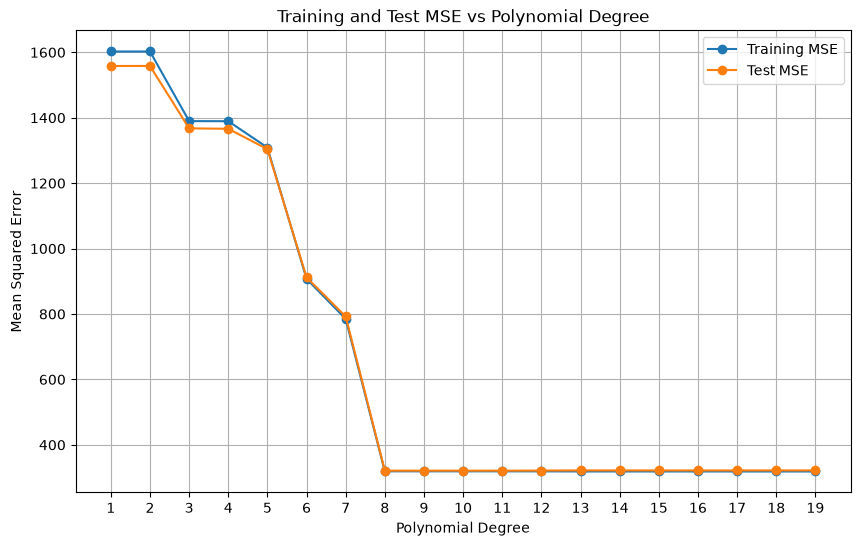

In [17]:
# EXPERIMENT 2
# Training MSE vs Test MSE

degree_values = []
train_errors = []
test_errors = []

for result in results:

    degree_values.append(result[0])
    train_errors.append(result[1])
    test_errors.append(result[2])

plt.figure(figsize=(10, 6))

plt.plot(
    degree_values,
    train_errors,
    marker="o",
    label="Training MSE"
)

plt.plot(
    degree_values,
    test_errors,
    marker="o",
    label="Test MSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.title("Training and Test MSE vs Polynomial Degree")

plt.xticks(degree_values)
plt.legend()
plt.grid(True)

plt.show()

In [18]:
# EXPERIMENT 3
# Residual analysis on validation data

residuals = np.asarray(y_val) - np.asarray(validation_predictions)

residual_mean = np.mean(residuals)
residual_min = np.min(residuals)
residual_max = np.max(residuals)

print("Residual Analysis")
print("-----------------")
print("Mean residual :", residual_mean)
print("Minimum       :", residual_min)
print("Maximum       :", residual_max)


Residual Analysis
-----------------
Mean residual : -0.19186657978903796
Minimum       : -67.33605748463332
Maximum       : 60.1408837664284


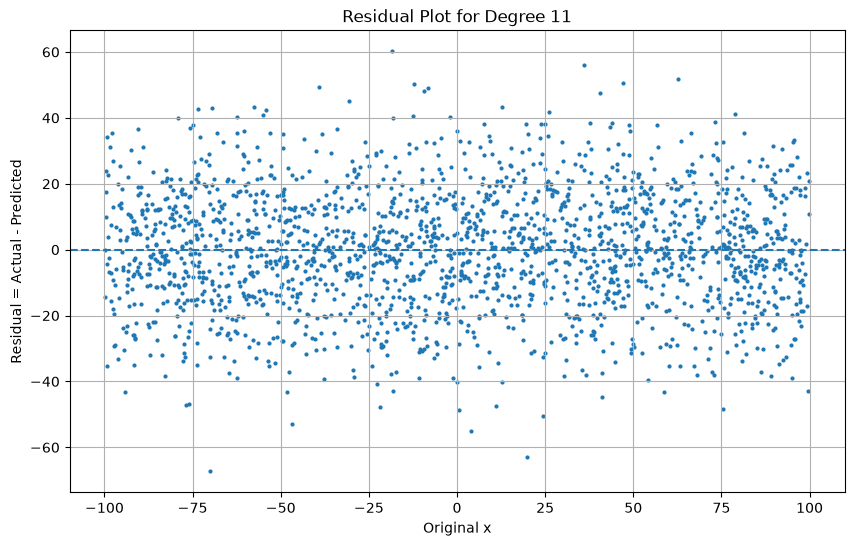

In [19]:
# Plot residuals

plt.figure(figsize=(10, 6))

plt.scatter(
    x_val,
    residuals,
    s=4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Original x")
plt.ylabel("Residual = Actual - Predicted")
plt.title(
    f"Residual Plot for Degree {best_degree}"
)

plt.grid(True)

plt.show()

In [20]:
# EXPERIMENT 4
# Learning curve

training_sizes = [size for size in [500, 1000, 2000, 3000, 4000, 5000, 6000]
                  if size <= len(x_train)]

learning_train_mse = []
learning_test_mse = []

for size in training_sizes:
    coefficients = polynomial_regression(
        x_train_scaled[:size],
        y_train[:size],
        best_degree
    )

    train_predictions = predict(x_train_scaled[:size], coefficients)
    test_predictions = predict(x_test_scaled, coefficients)

    train_error = mean_squared_error(y_train[:size], train_predictions)
    test_error = mean_squared_error(y_test, test_predictions)

    learning_train_mse.append(train_error)
    learning_test_mse.append(test_error)

    print(
        "Training samples:", size,
        "| Train MSE:", train_error,
        "| Test MSE:", test_error
    )


Training samples: 500 | Train MSE: 327.94162278130125 | Test MSE: 327.35966499129614
Training samples: 1000 | Train MSE: 306.8507530814388 | Test MSE: 326.25306634287654
Training samples: 2000 | Train MSE: 320.5561705071957 | Test MSE: 323.453364975782
Training samples: 3000 | Train MSE: 321.00138342465436 | Test MSE: 322.22146306791626
Training samples: 4000 | Train MSE: 316.0799148721443 | Test MSE: 321.16322567072774
Training samples: 5000 | Train MSE: 317.0540197976797 | Test MSE: 320.9816535796629
Training samples: 6000 | Train MSE: 319.0167435140113 | Test MSE: 321.01900454411634


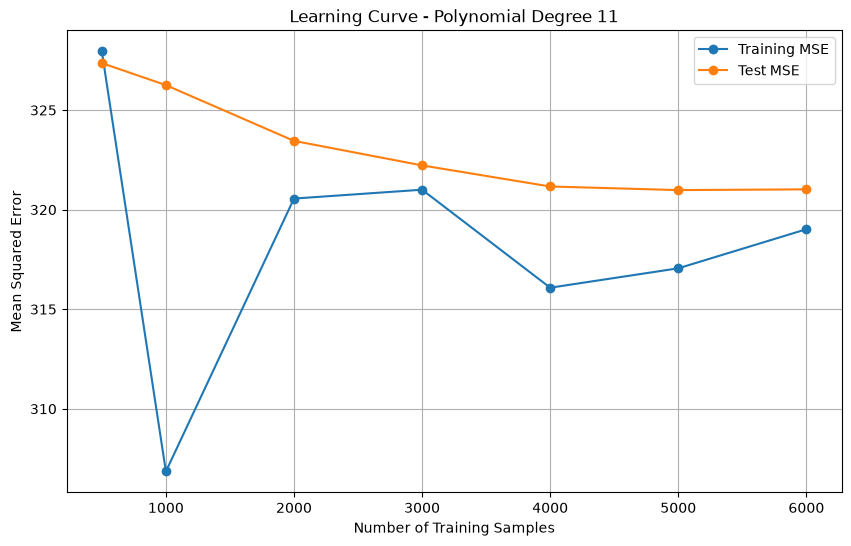

In [21]:
# Plot learning curve

plt.figure(figsize=(10, 6))

plt.plot(
    training_sizes,
    learning_train_mse,
    marker="o",
    label="Training MSE"
)

plt.plot(
    training_sizes,
    learning_test_mse,
    marker="o",
    label="Test MSE"
)

plt.xlabel("Number of Training Samples")
plt.ylabel("Mean Squared Error")
plt.title(
    f"Learning Curve - Polynomial Degree {best_degree}"
)

plt.legend()
plt.grid(True)

plt.show()